**The accuracy of each model on this dataset is listed below:**
Logistic Regression: 98.3%\ Random Forests: 96.4%\ Support Vector Machines (SVM):98.2%\ xg boost: 95.6%\ MLP: 97.58%\

By using these models, we hope to provide a valuable tool for medical professionals in predicting whether a breast tumor is malignant or benign.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.shape

(569, 33)

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [7]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [8]:
df.drop("Unnamed: 32", axis=1, inplace=True)

# map the diagnosis to binary values

Diagnosis (M = malignant, B = benign)

In [9]:
df['diagnosis'] = df['diagnosis'].map({'B':0, 'M':1})

In [10]:
X=df.drop('diagnosis', axis=1)
y=df['diagnosis']

In [11]:
# from imblearn.over_sampling import ADASYN
# adasyn = ADASYN(random_state=42)
# X, y = adasyn.fit_resample(X, y)

# Split the data into training and testing sets

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

# Standardize the data from sklearn.preprocessing

In [13]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

In [14]:
X_train_std

array([[-0.23055943, -0.12348985, -0.29680142, ..., -0.84082156,
        -0.8563616 , -0.76574773],
       [-0.2305946 , -0.22826757, -0.65795149, ..., -0.37706655,
        -1.3415819 , -0.41480748],
       [-0.2302707 ,  0.14553402, -1.23056444, ..., -0.04762652,
        -0.08997059,  0.4882635 ],
       ...,
       [-0.16718429,  0.03226081, -0.55578404, ..., -1.26179013,
        -0.6828391 , -1.27672587],
       [-0.23025553, -0.05552593,  0.10949242, ...,  1.07924018,
         0.4755842 ,  1.25530227],
       [-0.23061433, -0.56525537,  0.32333128, ..., -0.61952313,
        -0.30366032, -0.84348042]])

In [15]:
X_test_std

array([[-0.23672293, -0.48313229, -0.13285829, ..., -0.19338258,
         0.21048039,  0.22648723],
       [-0.23064105,  1.34906186,  0.51103428, ...,  1.01968394,
        -0.53341696, -1.00866239],
       [-0.23734763,  0.36358494,  0.0762286 , ...,  0.58868486,
        -0.07390369, -0.19132599],
       ...,
       [-0.23053833, -1.20977993, -0.2611616 , ..., -0.23099704,
        -0.4321955 ,  1.86687566],
       [-0.23669476, -0.10083521,  1.26659826, ...,  0.59965574,
         1.23394176,  1.98690408],
       [-0.23044361, -0.36419542, -1.19967661, ...,  0.66234652,
        -0.39202826,  1.95832589]])


# Visualizations

<AxesSubplot:xlabel='diagnosis', ylabel='count'>

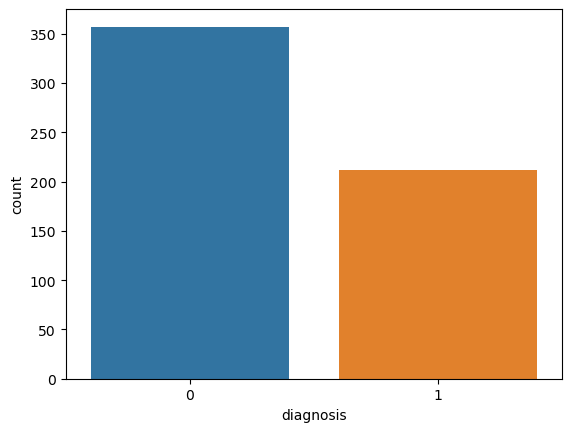

In [16]:
df['Malignant'] = pd.get_dummies(df['diagnosis'], drop_first = True)
df['diagnosis']=pd.Categorical(df['diagnosis'])
sns.countplot(x = 'diagnosis', data =df)

# Logistic Regression

In [17]:
logreg = LogisticRegression()
logreg.fit(X_train_std, y_train)
predictions1 = logreg.predict(X_test_std)
logreg_acc = accuracy_score(y_test, predictions1)
print("Accuracy of the Logistic Regression Model is: ", logreg_acc)

Accuracy of the Logistic Regression Model is:  0.9824561403508771


# Random Forest

In [18]:
rfc = RandomForestClassifier(n_estimators=300)
rfc.fit(X_train_std, y_train)
predictions4 = rfc.predict(X_test_std)
rfc_acc = accuracy_score(y_test, predictions4)
print("Accuracy of Random Forests Model is: ", rfc_acc)

Accuracy of Random Forests Model is:  0.9649122807017544


# Support Vector Machine

In [19]:
svc_model = SVC(kernel="rbf")
svc_model.fit(X_train_std, y_train)
predictions5 = svc_model.predict(X_test_std)
svm_acc = accuracy_score(y_test, predictions5)
print("Accuracy of SVM model is: ", svm_acc)

Accuracy of SVM model is:  0.9766081871345029


# XGBoost

In [20]:
model = XGBClassifier()
model.fit(X_train_std, y_train)
y_pred = model.predict(X_test_std)
xgb_acc = accuracy_score(y_test, y_pred)
print("Accuracy of XGBoost model is: ", xgb_acc)

Accuracy of XGBoost model is:  0.9766081871345029


# Multi-Layer Perceptron

In [21]:
mlp = MLPClassifier(random_state=1, max_iter=500) 
scores = cross_val_score(mlp, X_train_std, y_train, cv=5) 
mlp_acc = scores.mean()
print("Accuracy of MLP model is: ", mlp_acc)

Accuracy of MLP model is:  0.9647468354430379
